In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


import re
import string
from textstat import flesch_reading_ease, flesch_kincaid_grade
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

In [6]:
df = pd.read_csv('fake reviews dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (40432, 4)

Columns: ['category', 'rating', 'label', 'text_']


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [7]:
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nCategory distribution:")
print(df['category'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
None

Missing values:
category    0
rating      0
label       0
text_       0
dtype: int64

Label distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64

Category distribution:
category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: i

In [8]:
df['text_length'] = df['text_'].str.len()
df['word_count'] = df['text_'].str.split().str.len()
df['exclamation_count'] = df['text_'].str.count('!')
df['question_count'] = df['text_'].str.count('\?')
df['capital_ratio'] = df['text_'].str.count(r'[A-Z]') / df['text_length']
df['punctuation_count'] = df['text_'].apply(lambda x: sum(1 for c in x if c in string.punctuation))

sia = SentimentIntensityAnalyzer()
df['sentiment_compound'] = df['text_'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_pos'] = df['text_'].apply(lambda x: sia.polarity_scores(x)['pos'])
df['sentiment_neu'] = df['text_'].apply(lambda x: sia.polarity_scores(x)['neu'])
df['sentiment_neg'] = df['text_'].apply(lambda x: sia.polarity_scores(x)['neg'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text_'].apply(clean_text)

stop_words = set(stopwords.words('english'))
df['unique_words'] = df['cleaned_text'].apply(lambda x: len(set(word_tokenize(x)) - stop_words))
df['avg_word_length'] = df['cleaned_text'].apply(lambda x: np.mean([len(word) for word in word_tokenize(x)]) if word_tokenize(x) else 0)

print("Feature engineering completed")
print(f"New shape: {df.shape}")

Feature engineering completed
New shape: (40432, 17)


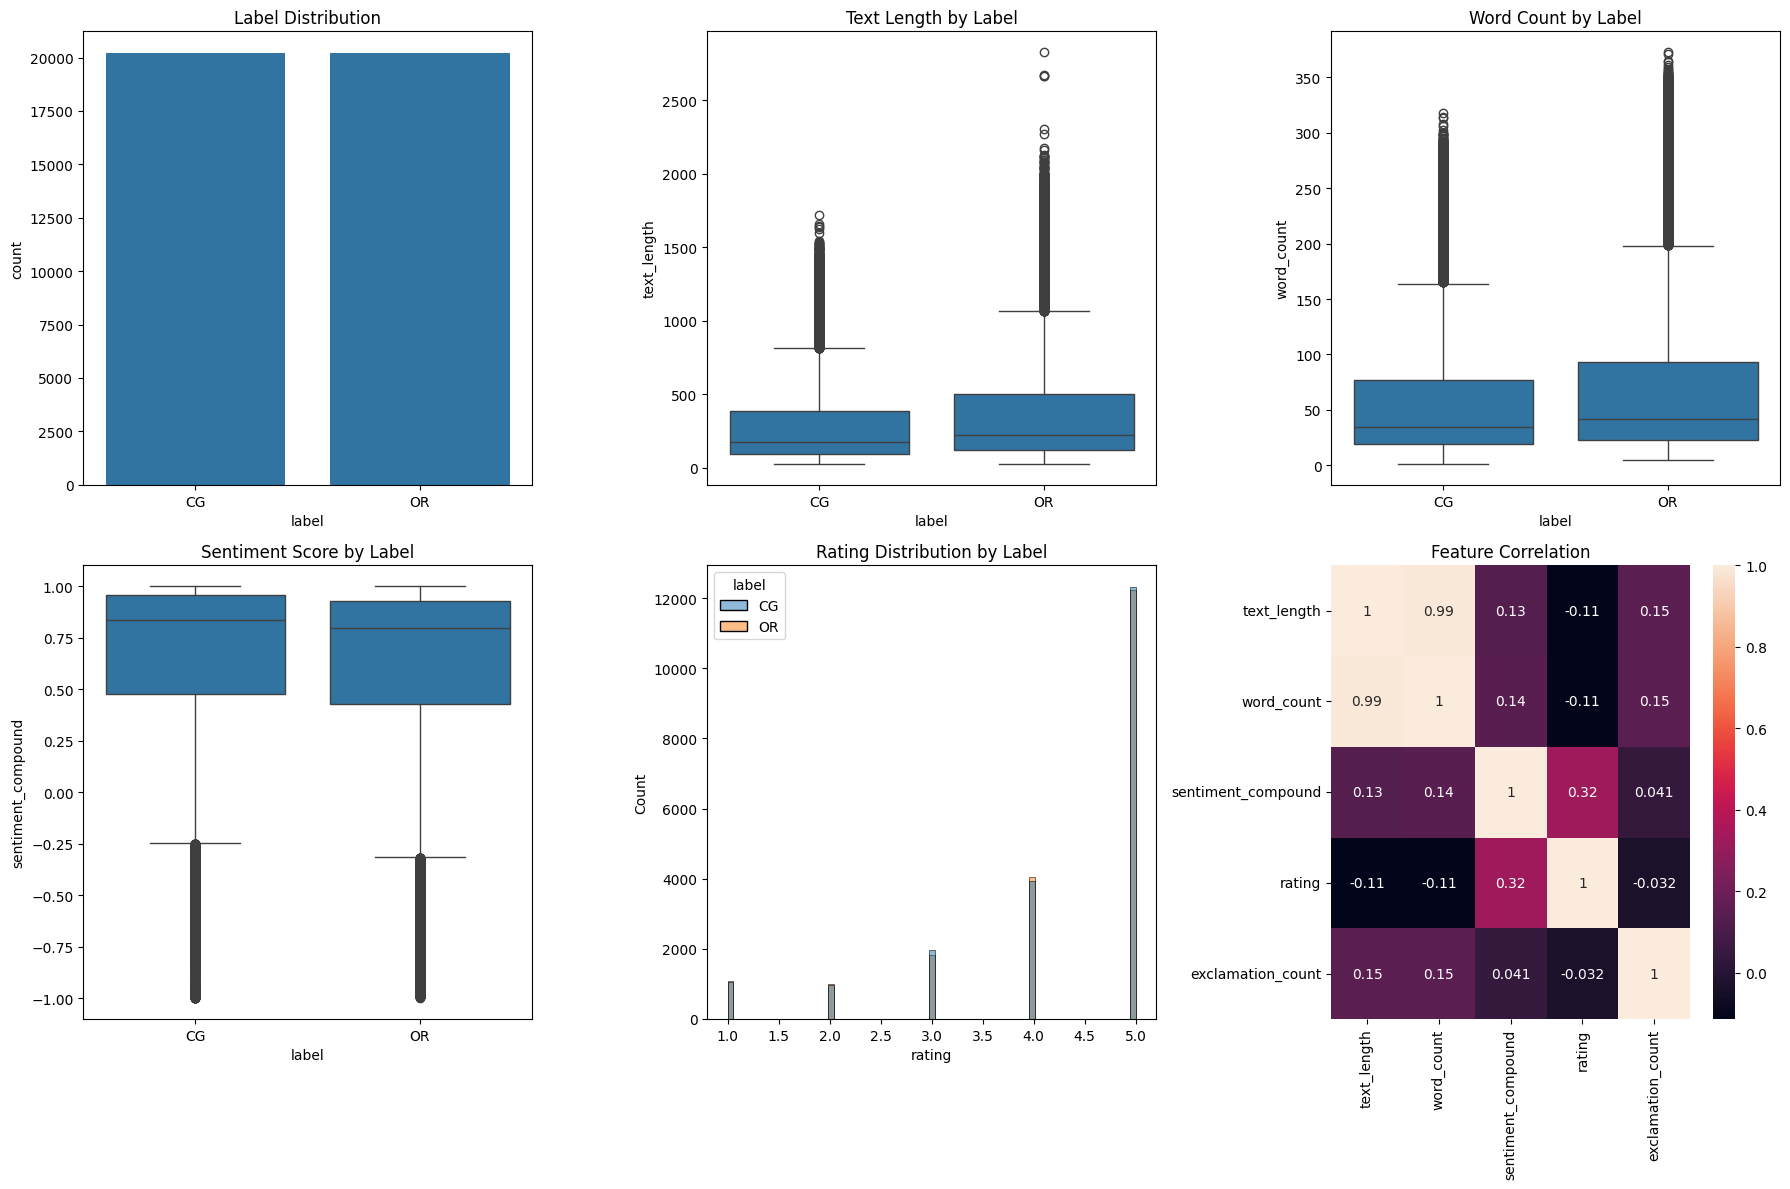

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.countplot(data=df, x='label', ax=axes[0,0])
axes[0,0].set_title('Label Distribution')

sns.boxplot(data=df, x='label', y='text_length', ax=axes[0,1])
axes[0,1].set_title('Text Length by Label')

sns.boxplot(data=df, x='label', y='word_count', ax=axes[0,2])
axes[0,2].set_title('Word Count by Label')

sns.boxplot(data=df, x='label', y='sentiment_compound', ax=axes[1,0])
axes[1,0].set_title('Sentiment Score by Label')

sns.histplot(data=df, x='rating', hue='label', ax=axes[1,1])
axes[1,1].set_title('Rating Distribution by Label')

df_sample = df.sample(1000, random_state=42)
correlation_matrix = df_sample[['text_length', 'word_count', 'sentiment_compound', 'rating', 'exclamation_count']].corr()
sns.heatmap(correlation_matrix, annot=True, ax=axes[1,2])
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

In [10]:
print("Statistical summary by label:")
numerical_features = ['text_length', 'word_count', 'sentiment_compound', 'rating', 'exclamation_count', 'unique_words']
for feature in numerical_features:
    print(f"\n{feature}:")
    print(df.groupby('label')[feature].describe())

Statistical summary by label:

text_length:
         count        mean         std   min    25%    50%    75%     max
label                                                                    
CG     20216.0  305.573506  307.037430  24.0   96.0  174.0  383.0  1717.0
OR     20216.0  396.970419  418.428047  28.0  121.0  224.0  498.0  2827.0

word_count:
         count       mean        std  min   25%   50%   75%    max
label                                                             
CG     20216.0  61.288237  61.799015  1.0  19.0  35.0  77.0  318.0
OR     20216.0  73.642610  76.078420  5.0  23.0  42.0  93.0  373.0

sentiment_compound:
         count      mean       std     min       25%    50%       75%     max
label                                                                        
CG     20216.0  0.634677  0.449289 -0.9997  0.475375  0.836  0.956200  0.9999
OR     20216.0  0.582339  0.488979 -0.9980  0.429350  0.796  0.926825  0.9994

rating:
         count      mean       std  m

In [11]:
le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])

le_label = LabelEncoder()
df['label_encoded'] = le_label.fit_transform(df['label'])
# tokenization
tfidf = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1,2), min_df=3, max_df=0.7)
tfidf_features = tfidf.fit_transform(df['cleaned_text']).toarray()

feature_columns = ['rating', 'category_encoded', 'text_length', 'word_count', 'exclamation_count', 
                  'question_count', 'capital_ratio', 'punctuation_count', 'sentiment_compound',
                  'sentiment_pos', 'sentiment_neu', 'sentiment_neg', 'unique_words', 'avg_word_length']

X_numerical = df[feature_columns].values
X_combined = np.hstack([X_numerical, tfidf_features])
y = df['label_encoded'].values

print(f"Feature matrix shape: {X_combined.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {np.bincount(y)}")

Feature matrix shape: (40432, 2014)
Target shape: (40432,)
Target distribution: [20216 20216]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Val distribution: {np.bincount(y_val)}")
print(f"Test distribution: {np.bincount(y_test)}")

Training set: (24258, 2014)
Validation set: (8087, 2014)
Test set: (8087, 2014)
Train distribution: [12129 12129]
Val distribution: [4043 4044]
Test distribution: [4044 4043]


In [13]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=1)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=1, verbose=1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_train_pred = best_rf.predict(X_train)
rf_val_pred = best_rf.predict(X_val)

print(f"Random Forest Best Parameters: {rf_grid.best_params_}")
print(f"RF Training Accuracy: {accuracy_score(y_train, rf_train_pred):.4f}")
print(f"RF Validation Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Random Forest Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
RF Training Accuracy: 0.8700
RF Validation Accuracy: 0.8376


In [14]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 0.9]
}

xgb = XGBClassifier(random_state=42, n_jobs=1, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='accuracy', n_jobs=1, verbose=1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_train_pred = best_xgb.predict(X_train)
xgb_val_pred = best_xgb.predict(X_val)

print(f"XGBoost Best Parameters: {xgb_grid.best_params_}")
print(f"XGB Training Accuracy: {accuracy_score(y_train, xgb_train_pred):.4f}")
print(f"XGB Validation Accuracy: {accuracy_score(y_val, xgb_val_pred):.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
XGBoost Best Parameters: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.9}
XGB Training Accuracy: 0.9730
XGB Validation Accuracy: 0.8987


In [15]:
cat_params = {
    'iterations': [100, 200],
    'depth': [6, 8],
    'learning_rate': [0.1, 0.2],
    'l2_leaf_reg': [1, 3]
}

cat = CatBoostClassifier(random_state=42, verbose=False)
cat_grid = GridSearchCV(cat, cat_params, cv=3, scoring='accuracy', n_jobs=1, verbose=1)
cat_grid.fit(X_train, y_train)

best_cat = cat_grid.best_estimator_
cat_train_pred = best_cat.predict(X_train)
cat_val_pred = best_cat.predict(X_val)

print(f"CatBoost Best Parameters: {cat_grid.best_params_}")
print(f"CatBoost Training Accuracy: {accuracy_score(y_train, cat_train_pred):.4f}")
print(f"CatBoost Validation Accuracy: {accuracy_score(y_val, cat_val_pred):.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
CatBoost Best Parameters: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.2}
CatBoost Training Accuracy: 0.9509
CatBoost Validation Accuracy: 0.8966


In [16]:
models = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'CatBoost': best_cat
}

results = {}
for name, model in models.items():
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results[name] = {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'test_auc': test_auc,
        'overfitting': train_acc - val_acc
    }

results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df.round(4))

best_model_name = results_df['val_acc'].idxmax()
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")

Model Comparison:
               train_acc  val_acc  test_acc  train_auc  val_auc  test_auc  \
Random Forest     0.8700   0.8376    0.8449     0.9465   0.9203    0.9235   
XGBoost           0.9730   0.8987    0.8995     0.9968   0.9674    0.9675   
CatBoost          0.9509   0.8966    0.9024     0.9911   0.9647    0.9662   

               overfitting  
Random Forest       0.0323  
XGBoost             0.0743  
CatBoost            0.0542  

Best Model: XGBoost


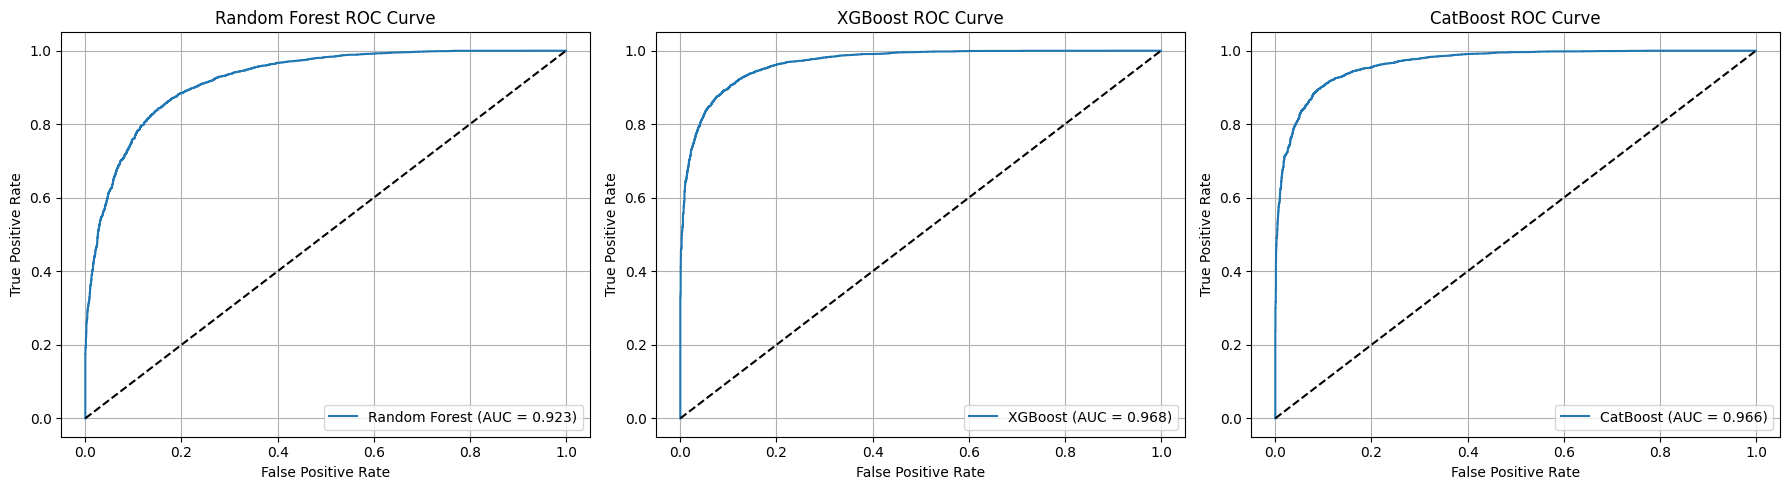

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    axes[i].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    axes[i].plot([0, 1], [0, 1], 'k--')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{name} ROC Curve')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Final Test Accuracy with XGBoost: 0.8995
Final Test AUC: 0.9675

Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.90      0.90      4044
        Fake       0.90      0.90      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



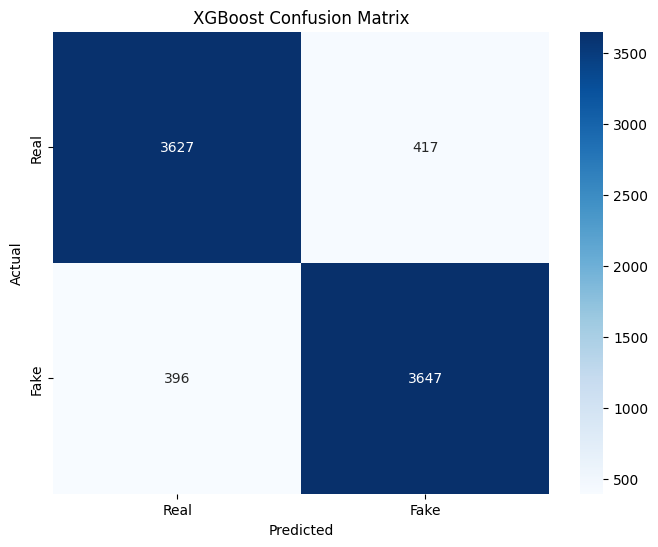

In [18]:
final_predictions = best_model.predict(X_test)
final_probabilities = best_model.predict_proba(X_test)[:, 1]

print(f"Final Test Accuracy with {best_model_name}: {accuracy_score(y_test, final_predictions):.4f}")
print(f"Final Test AUC: {roc_auc_score(y_test, final_probabilities):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_predictions, target_names=['Real', 'Fake']))

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
import joblib

joblib.dump(
    {
        'model': best_model,
        'tfidf_vectorizer': tfidf,
        'label_encoder': le_label,
        'category_encoder': le_category,
        'feature_columns': feature_columns
    },
    'fake_review_detection_model.joblib'
)

print(f"Best model ({best_model_name}) saved successfully as joblib!")


Best model (XGBoost) saved successfully as joblib!


In [20]:
test_indices = np.random.choice(len(X_test), 20, replace=False)
sample_X = X_test[test_indices]
sample_y_true = y_test[test_indices]
sample_y_pred = best_model.predict(sample_X)
sample_proba = best_model.predict_proba(sample_X)[:, 1]

results_comparison = pd.DataFrame({
    'Actual': [le_label.inverse_transform([y])[0] for y in sample_y_true],
    'Predicted': [le_label.inverse_transform([y])[0] for y in sample_y_pred],
    'Probability_Fake': sample_proba,
    'Correct': sample_y_true == sample_y_pred
})

print("Sample Predictions:")
print(results_comparison)

Sample Predictions:
   Actual Predicted  Probability_Fake  Correct
0      OR        OR          0.660034     True
1      CG        CG          0.015986     True
2      OR        OR          0.699741     True
3      CG        CG          0.124142     True
4      OR        OR          0.943978     True
5      OR        OR          0.977087     True
6      OR        CG          0.270255    False
7      CG        CG          0.003178     True
8      CG        CG          0.017503     True
9      OR        OR          0.997282     True
10     OR        CG          0.357168    False
11     OR        OR          0.954868     True
12     OR        CG          0.452871    False
13     OR        OR          0.996372     True
14     CG        OR          0.674145    False
15     CG        CG          0.004396     True
16     OR        OR          0.997718     True
17     CG        CG          0.033583     True
18     OR        OR          0.999641     True
19     OR        OR          0.868184   

In [21]:
def predict_review(text, rating=5.0, category='Home_and_Kitchen_5'):
    with open('fake_review_detection_model.joblib', 'rb') as f:
        model_data = joblib.load(f)
    
    model = model_data['model']
    tfidf_vec = model_data['tfidf_vectorizer']
    le_label = model_data['label_encoder']
    le_category = model_data['category_encoder']
    feature_cols = model_data['feature_columns']
    
    text_length = len(text)
    word_count = len(text.split())
    exclamation_count = text.count('!')
    question_count = text.count('?')
    capital_ratio = sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
    punctuation_count = sum(1 for c in text if c in string.punctuation)
    
    sia = SentimentIntensityAnalyzer()
    sentiment_scores = sia.polarity_scores(text)
    
    cleaned_text = clean_text(text)
    stop_words = set(stopwords.words('english'))
    unique_words = len(set(word_tokenize(cleaned_text)) - stop_words)
    avg_word_length = np.mean([len(word) for word in word_tokenize(cleaned_text)]) if word_tokenize(cleaned_text) else 0
    
    try:
        category_encoded = le_category.transform([category])[0]
    except:
        category_encoded = 0
    
    numerical_features = np.array([
        rating, category_encoded, text_length, word_count, exclamation_count,
        question_count, capital_ratio, punctuation_count, sentiment_scores['compound'],
        sentiment_scores['pos'], sentiment_scores['neu'], sentiment_scores['neg'],
        unique_words, avg_word_length
    ]).reshape(1, -1)
    
    tfidf_features = tfidf_vec.transform([cleaned_text]).toarray()
    X_combined = np.hstack([numerical_features, tfidf_features])
    
    prediction = model.predict(X_combined)[0]
    probability = model.predict_proba(X_combined)[0]
    
    result = le_label.inverse_transform([prediction])[0]
    confidence = max(probability)
    
    return result, confidence, probability[1]

test_review_1 = "Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty"
test_review_2 = "This product is exactly what I was looking for. Good quality and fast shipping."

for i, review in enumerate([test_review_1, test_review_2], 1):
    pred, conf, fake_prob = predict_review(review)
    print(f"\nTest Review {i}: '{review[:50]}...'")         
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf:.3f}")
    print(f"Fake Probability: {fake_prob:.3f}")


Test Review 1: 'Love this!  Well made, sturdy, and very comfortabl...'
Prediction: CG
Confidence: 0.980
Fake Probability: 0.020

Test Review 2: 'This product is exactly what I was looking for. Go...'
Prediction: OR
Confidence: 0.505
Fake Probability: 0.505
